# Tarefa 1: Vision Transformer Feature Extraction & Visualization

This notebook demonstrates feature extraction using a Vision Transformer (ViT) model on the Tiny ImageNet dataset. It visualizes high-dimensional features using UMAP dimensionality reduction to understand how the model represents different image classes.

*This notebook was executed with Google Colab*

## 1. Install and Import Dependencies

In [1]:
!pip install torch torchvision transformers umap-learn pillow

In [2]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from transformers import ViTModel, ViTImageProcessor
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import umap
import os
from PIL import Image

## 2. Configuration and Model Loading

In [4]:
print("Cargando modelo ViT")

procesador = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTModel.from_pretrained('google/vit-base-patch16-224')
model.eval() # Modo avaliación

# Usar CUDA se existe
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
model.to(device)

Cargando modelo ViT


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Usando dispositivo: cuda


ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ViTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (attention): ViTSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ViTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ViTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ViTOutput(
          (d

## 3. Dataset Preparation (Tiny ImageNet)

In [ ]:
from torch.utils.data import Subset

# Clonar o repositorio e acceder ao directorio de train
# ou usar o directorio se xa existe no sistema

if os.path.exists("./tiny-imagenet-200/"):
    print("Xa existe o directorio :)")
    train = "./tiny-imagenet-200/train/"
elif not os.path.exists("./IMagenet/"):
    print("Clonando Tiny ImageNet desde GitHub... :)")
    os.system("git clone https://github.com/seshuad/IMagenet.git")
    print("Clonado exitosamente")
    train = "./IMagenet/tiny-imagenet-200/train/"
else:
    train = "./IMagenet/tiny-imagenet-200/train/"



# Transformacións necesarias para ViT (Reseize a 224x224 e Normalización)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=procesador.image_mean, std=procesador.image_std)
])

# Definimos o dataset completo
full_dataset = datasets.ImageFolder(root=train, transform=transform)

n_images = 20
n_clases = 5

# Seleccionar as primeiras 20 imaxes de cada unha das 10 primeiras clases

indices = []
counts = {i: 0 for i in range(n_clases)}
for idx, (_, label) in enumerate(full_dataset.samples):
    if label < n_clases and counts[label] < n_images:
        indices.append(idx)
        counts[label] += 1

subset_dataset = Subset(full_dataset, indices)
dataloader = DataLoader(subset_dataset, batch_size=16, shuffle=False)

## 4. Feature Extraction

In [7]:
features = []
labels = []

print(f"Extraendo características de {len(subset_dataset)} imaxes...")
with torch.no_grad():
    for imgs, target in dataloader:
        imgs = imgs.to(device)
        # O modelo devolve a última capa oculta
        outputs = model(imgs)
        # O CLS token é o primeiro token da secuencia (índice 0)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        
        features.append(cls_embeddings)
        labels.append(target.numpy())

features = np.concatenate(features, axis=0)
labels = np.concatenate(labels, axis=0)

Extraendo características de 100 imaxes...


## 5. UMAP Visualization and Results

Calculando proxección UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


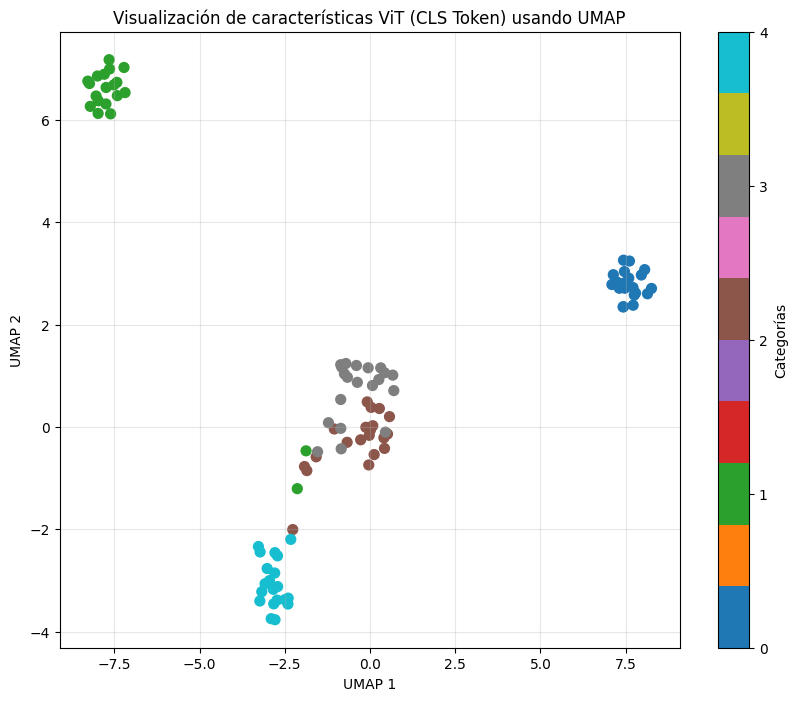

In [10]:
print("Calculando proxección UMAP...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='tab10', s=50)
plt.colorbar(scatter, ticks=range(n_clases), label='Categorías')
plt.title('Visualización de características ViT (CLS Token) usando UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)
plt.show()